# описание датасета и загрузка

In [604]:
from sklearn.datasets import fetch_openml
import pandas as pd

was_openml_error = False

try: # по умолчанию по тз нужно парсить вот так:
    df = fetch_openml("titanic", version=1, as_frame=True).frame
except: # но был прецедент неотвечания серверов openml поэтому на случай подобных ошибок сделаем парс с моего гитхаба
    was_openml_error = True
    df = pd.read_csv('https://raw.githubusercontent.com/ismylvdya/titanic-RandomForest/refs/heads/main/titanic-40945-dataset/dataset/tables/data.csv') # нету PK-столбца аля passenger_ID поэтому аргумент index_col не определяем
   
print('was_openml_error:', was_openml_error) 
    
df

was_openml_error: False


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


на момент 1.06.2026 16:00 (и весь последующий вечер и весь следующий день) сервера openml не отвечали (падало с `HTTP Error 504: Gateway Time-out`), поэтому временно загрузим csv и метаданные с зеркала openml на [gitlab](https://gitlab.com/data/d/openml/40945) (по идее данный csv должен быть полностью аналогичен вышевызываемой `version=1`) 

UPD: да, датасеты аналогичны с точностью до типов данных столбцов и NaN/'?'



true-описание столбцов из [features.json](./titanic-40945-dataset/dataset/features.json) (эталонная информация от создателя датасета, а не полученная из ручного анализа df)

| characteristic | pclass | survived | name | sex | age | sibsp | parch | ticket | fare | cabin | embarked | boat | body | home.dest |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| index | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 |
| data_type | numeric | nominal | string | nominal | numeric | numeric | numeric | string | numeric | string | nominal | string | numeric | string |
| is_target | false | true | false | false | false | false | false | false | false | false | false | false | false | false |
| missing_values | 0 | 0 | 0 | 0 | 263 | 0 | 0 | 0 | 1 | 1014 | 2 | 823 | 1188 | 564 |
| nominal_values | — | 0, 1 | — | female, male | — | — | — | — | — | — | C, Q, S | — | — | — |


- **pclass** — класс каюты пассажира (1, 2, 3)
- **survived** — выжил ли пассажир (0 — нет, 1 — да)   (target)
- **name** — имя пассажира
- **sex** — пол (male/female)
- **age** — возраст
- **sibsp** — количество братьев/сестёр и супругов на борту
- **parch** — количество родителей и детей на борту
- **ticket** — номер билета
- **fare** — стоимость билета
- **cabin** — номер каюты
- **embarked** — порт посадки (C — Шербур, Q — Квинстаун, S — Саутгемптон)
- **boat** — номер спасательной шлюпки (если выжил)
- **body** — номер тела (если не выжил и тело было найдено)
- **home.dest** — место проживания / пункт назначения

# препроцессинг до `train_test_split`

❗️ OneHotEncoding и заполнение NaN происходит ПОСЛЕ `train_test_split` (во время определения `Pipepline`, во избежание data leakage из train в test) 

In [605]:
print(f'{df.shape[0]} сэмлов (это без шапки csv)\n{df.shape[1]} фичей (без индекса)')

1309 сэмлов (это без шапки csv)
14 фичей (без индекса)


**предварительный** план относительно каждой фичи такой:
- удаляем за логической ненадобностью:
    - `name`, 
    - `ticket` -- просто номер билета, в котором нет ни номера каюты ни класса,  
    - `home.dest` -- по этой же логике логично убрать и `embarked`, но, т.к. у него всего 3 уникальных значения, оставим, не жалко
- удаляем, т.к. явный типичный data leakage:
    - `boat` -- если значение отлично от `NaN`/`?` значит пассажир выжил
    - `body` -- если значение отлично от `NaN`/`?` значит пассажир не выжил
- оставляем, категориальный:
    - `embarked` -- некорректно конвертировать город в числа -- один город не больше другого в каком бы то ни было смысле
- оставляем, числовые:
    - `pclass`, 
    - `survived`, 
    - `sex` -- конвертнем в {0,1}, 
    - `age`, 
    - `sibsp`, 
    - `parch`,
    - `fare` -- видится, что в контексте классового неравенства в данном случае куда важнее `pclass` или первая буква в `cabin`, но на всякий случай оствим цену билета тоже -- может быть такое что человек с деньгами сел в 3 класс но дал взятку во время бедствия и выжил и наборот -- какие-то люди бесплатно получили билет в 1-ый класс но т.к. у них не было денег, они не смогли пробиться во время бедствия,
    - `cabin` 
        -   -- формат кабин `'A123'`, первая буква обозначает номер палубы ([причем](https://www.kaggle.com/code/ccastleberry/titanic-cabin-features): A,B,C -- верхние палубы, 1-ый класс, D,E,F,G,T -- в основном 2 и 3 классы), можно взять только первую букву и конвертнуть в целые числа -- считаю, что это равносильный переход, т.к. у фичи явно порядковый тип, и мы не придумаем себе новые связи между значениями столбца, конвертировав их в числа 
        - вопрос остается только с NaN значениями: если их мало то просто заменю на медиану, если их очень много -- просто удалю столбец

## анализ пропусков

посмотрим на пропуски -- мб из-за слишком большого кличества пропусков в каких-то столбцах эти столбцы нужно будет удалить:

In [606]:
# только для датасета с моего гитхаба
# в случае датасета с моего гитхаба все NaN будут заменены на '?' и df.isna().mean() выдаст всё по нулям 

if was_openml_error:
    df.isna().mean()

In [607]:
# только для датасета с моего гитхаба

# заменим '?' обратно на NaN:

import numpy as np

if was_openml_error:
    df = df.replace({'?': np.nan})

In [608]:
# и еще раз

df.isna().mean()

pclass       0.000000
survived     0.000000
name         0.000000
sex          0.000000
age          0.200917
sibsp        0.000000
parch        0.000000
ticket       0.000000
fare         0.000764
cabin        0.774637
embarked     0.001528
boat         0.628724
body         0.907563
home.dest    0.430863
dtype: float64

в `age` же 20% процентов пропусков -- заменим на медиану, ничего не остается. НО заменим уже после `train_test_split` внутри Pipeline с помощью `SimpleImputer(strategy='median')`, т.к. это замена на статистическое значение, что корректно делать только отдельно независимо внутри train и test выборки, иначе может быть data leakage из train в test

у `fare` только 1 пропуск (один сэмпл) -- заменим на медиану

в `cabin` 77% пропусков -- с чистой душой удаляем, это был спорный столбец, который нужно было бы еще преобразовывать

НО перед этим создадим отдельный бинарный столбец `is_cabin`: `1` если `cabin` известен, `0` если `cabin` NaN -- может быть важно для модели 

все остальные фичи с пропусками УЖЕ приговорены к удалению


## приведения типов

In [609]:
for column in df.columns:
    print(df[column].value_counts(), end='\n\n')

pclass
3    709
1    323
2    277
Name: count, dtype: int64

survived
0    809
1    500
Name: count, dtype: int64

name
Connolly, Miss. Kate             2
Kelly, Mr. James                 2
Allen, Miss. Elisabeth Walton    1
Ilmakangas, Miss. Ida Livija     1
Ilieff, Mr. Ylio                 1
                                ..
Hart, Miss. Eva Miriam           1
Harris, Mr. Walter               1
Harris, Mr. George               1
Harper, Rev. John                1
Zimmerman, Mr. Leo               1
Name: count, Length: 1307, dtype: int64

sex
male      843
female    466
Name: count, dtype: int64

age
24.0000    47
22.0000    43
21.0000    41
30.0000    40
18.0000    39
           ..
0.3333      1
22.5000     1
70.5000     1
0.6667      1
26.5000     1
Name: count, Length: 98, dtype: int64

sibsp
0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64

parch
0    1002
1     170
2     113
3       8
4       6
5       6
6       2
9       2
Name: count, dty

In [610]:
df.dtypes

pclass          int64
survived     category
name           object
sex          category
age           float64
sibsp           int64
parch           int64
ticket         object
fare          float64
cabin          object
embarked     category
boat           object
body          float64
home.dest      object
dtype: object

In [611]:
# только для датасета с моего гитхаба

if was_openml_error:
    df['age'][df['age'].notna()].max()  # [df['fare'].notna()] потому что max пытается сравнивать NaN с str

In [612]:
# только для датасета с моего гитхаба

if was_openml_error:
    df['fare'][df['fare'].notna()].max()

то есть у нас столбцы `age` и `fare` содержат строки.. 
также надо заменить в `sex` male,female на {0,1}

.. и сделать OHE для `embarked` но это уже сделаем в Pipeline после train_test_split (опять же риск data leakage)

In [613]:
# только для датасета с моего гитхаба

if was_openml_error:
    df['age'] = df['age'].astype(float)
    df['fare'] = df['fare'].astype(float)

In [614]:
# т.к. survived по умолчанию имеет тип category 

df['survived'] = df['survived'].astype(int)

In [615]:
df['sex'] = df['sex'].map({'male' : 0, 'female': 1}).astype(int) # .astype(int) т.к. sex по умолчанию имеет тип category 

## создание новых столбцов

### логарифмирование

посмотрим надо ли как-то преобразовывать распределение float-столбцов:

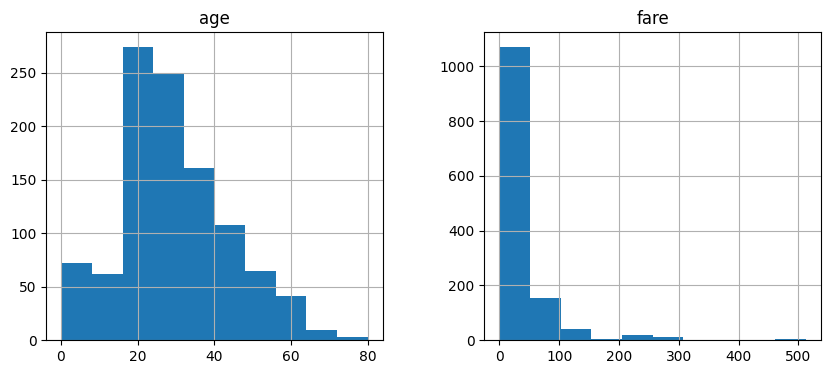

In [616]:
df[['age', 'fare']].hist(figsize=(10, 4))
None

с `age` все номарльно

фичу `fare` же можно прологарифмировать, т.к. она распределена $\pm$ экспоненциально, сделав же логарифмирование мы "растянем" значения около нуля и "сплотим" бОльшие значения, что позволит модели точнее перебирать предикаты в месте "наибольшего скопления" по данной фиче

In [617]:
df['fare'].min()

np.float64(0.0)

есть нули соответственно сдвигаем логарифм на 1 вправо:

In [618]:
df['fare'] = np.log(df['fare']+1)

### создание бинарных

In [619]:
# видится что факт того что человек был один без семьи хоть как-то но должен коррелировать с его выживаемостью поэтому 
# создадим столбец is_alone (1, если человек был один без семьи, 0 иначе)

df['is_alone'] = ( (df['sibsp'] + df['parch']) == 0).astype(int)

# и перемещаем его на место после sibsp и patch:
df.insert(df.columns.get_loc('parch') + 1, 'is_alone', df.pop('is_alone'))  # df.pop('is_alone') удаляем столбец из df и возвращает его как Series

In [620]:
# также создадим столбец is_cabin (1, если cabin известна, 0 если NaN)

df['is_cabin'] = df['cabin'].notna().astype(int)

# и перемещаем его на место после sibsp и patch:
df.insert(df.columns.get_loc('cabin') + 1, 'is_cabin', df.pop('is_cabin'))  # df.pop('is_cabin') удаляем столбец из df и возвращает его как Series

df

,pclass,survived,name,sex,age,sibsp,parch,is_alone,ticket,fare,cabin,is_cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",1,29.0000,0,0,1,24160,5.358177,B5,1,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",0,0.9167,1,2,0,113781,5.027492,C22 C26,1,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",1,2.0000,1,2,0,113781,5.027492,C22 C26,1,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",0,30.0000,1,2,0,113781,5.027492,C22 C26,1,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,25.0000,1,2,0,113781,5.027492,C22 C26,1,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",1,14.5000,1,0,0,2665,2.737881,NaN,0,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",1,NaN,1,0,0,2665,2.737881,NaN,0,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",0,26.5000,0,0,1,2656,2.107178,NaN,0,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",0,27.0000,0,0,1,2670,2.107178,NaN,0,C,NaN,NaN,NaN


## удаление столбцов

In [621]:
df = df.drop(columns=['name', 'ticket', 'home.dest', 'boat', 'body', 'cabin'])

df

,pclass,survived,sex,age,sibsp,parch,is_alone,fare,is_cabin,embarked
0,1,1,1,29.0000,0,0,1,5.358177,1,S
1,1,1,0,0.9167,1,2,0,5.027492,1,S
2,1,0,1,2.0000,1,2,0,5.027492,1,S
3,1,0,0,30.0000,1,2,0,5.027492,1,S
4,1,0,1,25.0000,1,2,0,5.027492,1,S
...,...,...,...,...,...,...,...,...,...,...
1304,3,0,1,14.5000,1,0,0,2.737881,0,C
1305,3,0,1,NaN,1,0,0,2.737881,0,C
1306,3,0,0,26.5000,0,0,1,2.107178,0,C
1307,3,0,0,27.0000,0,0,1,2.107178,0,C


## гистаграммы, корреляции и scatter

In [622]:
cat_cols = ['embarked']  
num_cols = list(filter(lambda x: x not in cat_cols+['survived'], list(df.columns))) # все остальные фичи не считая таргета

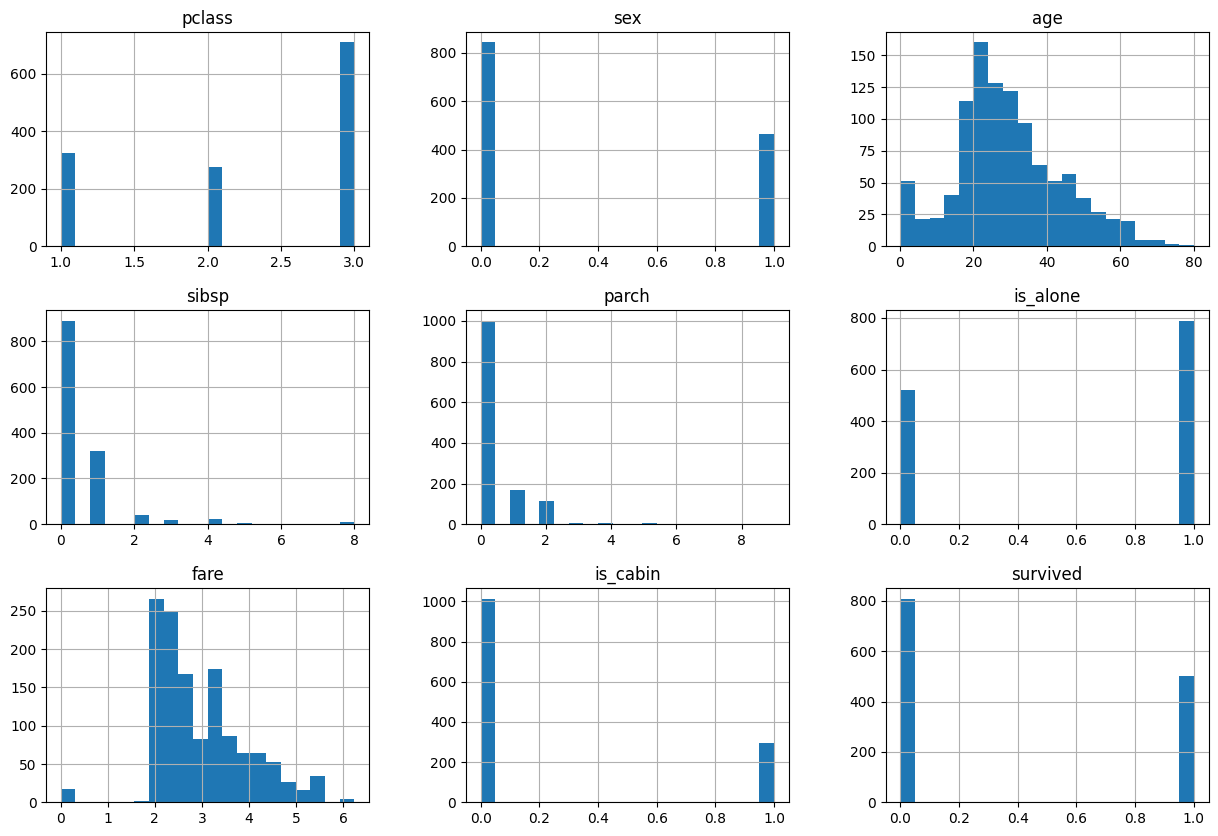

In [623]:
df[num_cols+['survived']].hist(bins=20, figsize=(15, 10))
None

2/3 не выжило это грустно

In [624]:
df[num_cols+['survived']].corr().style.background_gradient(
    cmap='Greens',
    gmap=df[num_cols+['survived']].corr().abs(), # чтобы цвет зависил только от величины модуля корреляции
    axis=None
)

,pclass,sex,age,sibsp,parch,is_alone,fare,is_cabin,survived
pclass,1.000000,-0.124617,-0.408106,0.060832,0.018322,0.147393,-0.685974,-0.713857,-0.312469
sex,-0.124617,1.000000,-0.063646,0.109609,0.213125,-0.284537,0.250318,0.137396,0.528693
age,-0.408106,-0.063646,1.000000,-0.243699,-0.150917,0.128755,0.194624,0.289740,-0.055513
sibsp,0.060832,0.109609,-0.243699,1.000000,0.373587,-0.591077,0.311611,-0.009064,-0.027825
parch,0.018322,0.213125,-0.150917,0.373587,1.000000,-0.549022,0.323512,0.036806,0.082660
is_alone,0.147393,-0.284537,0.128755,-0.591077,-0.549022,1.000000,-0.469822,-0.175812,-0.201719
fare,-0.685974,0.250318,0.194624,0.311611,0.323512,-0.469822,1.000000,0.576252,0.304728
is_cabin,-0.713857,0.137396,0.289740,-0.009064,0.036806,-0.175812,0.576252,1.000000,0.302250
survived,-0.312469,0.528693,-0.055513,-0.027825,0.082660,-0.201719,0.304728,0.302250,1.000000


линейная корреляция таргета есть и относительно сильная -- от `sex`, линейные модели справились бы этой задачей довольно хорошо
    
эта корреляция положительная то есть женщины выживали горадо чаще мужчин

на втором месте по модулю корреляция таргета от `pclass` -- она отрицательная, то есть чем больше значение класса тем меньше шансов на спасение -- ожидаемо

на третьем месте -- `is_alone` -- опять же отрицательная то есть у одиноких людей при прочих равных было меньше шансов спастись. Отдельно подчеркну что корреляция таргета с `is_alone` заметно больше чем с `sibsp` и `parch`, что говорит о том что `is_alone` был создан не зря 

аналогично для `fare` и `is_cabin` -- 0.3  это довольно неплохая корреляция которая может несколько улучшить качество классификации

как и ожидалось сильная линейная корреляция также есть и у созданного нами `is_alone` от `sibsp` с `parch` -- примерно половина датасета ехала на титанике одна

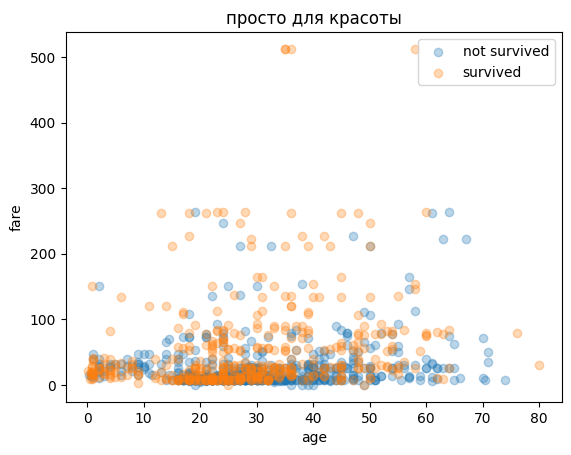

In [625]:
# scatter просто для красоты. age и fare единственные столбцы распределенные хотя бы не бинарно

import matplotlib.pyplot as plt

feature1 = 'age'
feature2 = 'fare'

df_for_scatter = df[df[feature1].notna() & df[feature2].notna()]   # т.к. у age и fare есть NaN, которые scatter не отобразит, лучше один раз сделать нужную копию датасета чем в построении несоклько раз использвоать маски на проверку NaN

# scatter отдельно для каждого класса (чтобы легенда была)
for (class_label, class_name) in [(0, 'not survived'), (1, 'survived')]:  
    class_mask = (df_for_scatter['survived'] == class_label)  
    plt.scatter(df_for_scatter[feature1][class_mask], np.exp(df_for_scatter[feature2][class_mask])-1, label=class_name, alpha=0.3) # np.exp()-1 т.к. у нас fare логарифмирван np.log(+1) а на scatter хочется лицезреть реальное распределение  
  
plt.title('просто для красоты')  
plt.xlabel(feature1)  
plt.ylabel(feature2)  
plt.legend()  
plt.show()

# `train_test_split`

In [626]:
from sklearn.model_selection import train_test_split

# как в тз

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(df[num_cols+cat_cols], df['survived'], test_size=0.2, random_state=RANDOM_STATE)

In [627]:
X_train

,pclass,sex,age,sibsp,parch,is_alone,fare,is_cabin,embarked
772,3,0,17.0,0,0,1,2.185579,0,S
543,2,0,36.0,0,0,1,2.442347,0,S
289,1,1,18.0,0,2,0,4.390119,1,S
10,1,0,47.0,1,0,0,5.431646,1,C
147,1,0,NaN,0,0,1,3.770459,0,S
...,...,...,...,...,...,...,...,...,...
1095,3,1,NaN,0,0,1,2.155152,0,Q
1130,3,1,18.0,0,0,1,2.171907,0,S
1294,3,0,28.5,0,0,1,2.839078,0,S
860,3,1,26.0,0,0,1,2.188856,0,S


# препроцессинг после `train_test_split`

## заполнение пропусков и One Hot Encoding

One Hot Encoding, замена NaN на медиану(для `age`)/моду(для `embarked`)

нормализация числовых фич не нужна так как используемой моделью будет RandomForest а деревья не чувствительны к нормализации 

In [628]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# определяем пайплайн препроцессинга (отдельно для числовых и категориальных фич), чтобы потом подать его на вход в Pipeline-модели
# этот пайплайн препроцессинга будет работьа для train и для test независимо
# для числовых фичей толкьо заполнение NaN медианой (StandardScaler не требуется так как у нас деревья)
# для категориальных -- заполнение NaN модой (т.к. категории) и One Hot Encoding


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')) 
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # handle_unknown='ignore' -- в случае если в test попадется категория которой не было в train (что почти невозможно) она проигнорируется, ошибки не будет  
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# обучение-инференс

In [629]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## подбор гиперпараметров 
-- определение, обучение и предикт в цикле

для гипермараметров представленных в первых строчках ниже построим accuracy-кривые обучения и зафиксируем гиперпараметры которые дали лучшие результаты (которые дали accuracy >= 0.8)

{'accuracy': 0.8129770992366412, 'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 10}

{'accuracy': 0.8091603053435115, 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 70}

{'accuracy': 0.8091603053435115, 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 130}

{'accuracy': 0.8091603053435115, 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 430}

{'accuracy': 0.8091603053435115, 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 450}

{'accuracy': 0.8091603053435115, 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 470}

{'accuracy': 0.8091603053435115, 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 490}

{'accuracy': 0.8091603053435115, 'max_depth': 50, 'min_samples_leaf': 2, 'n_estimators': 70}

{'accuracy': 0.8091603053435115, 'max_depth': 50, 'min_samples_leaf': 2, 'n_estimators': 130}

{'accuracy': 0.8091603053435115, 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 70}



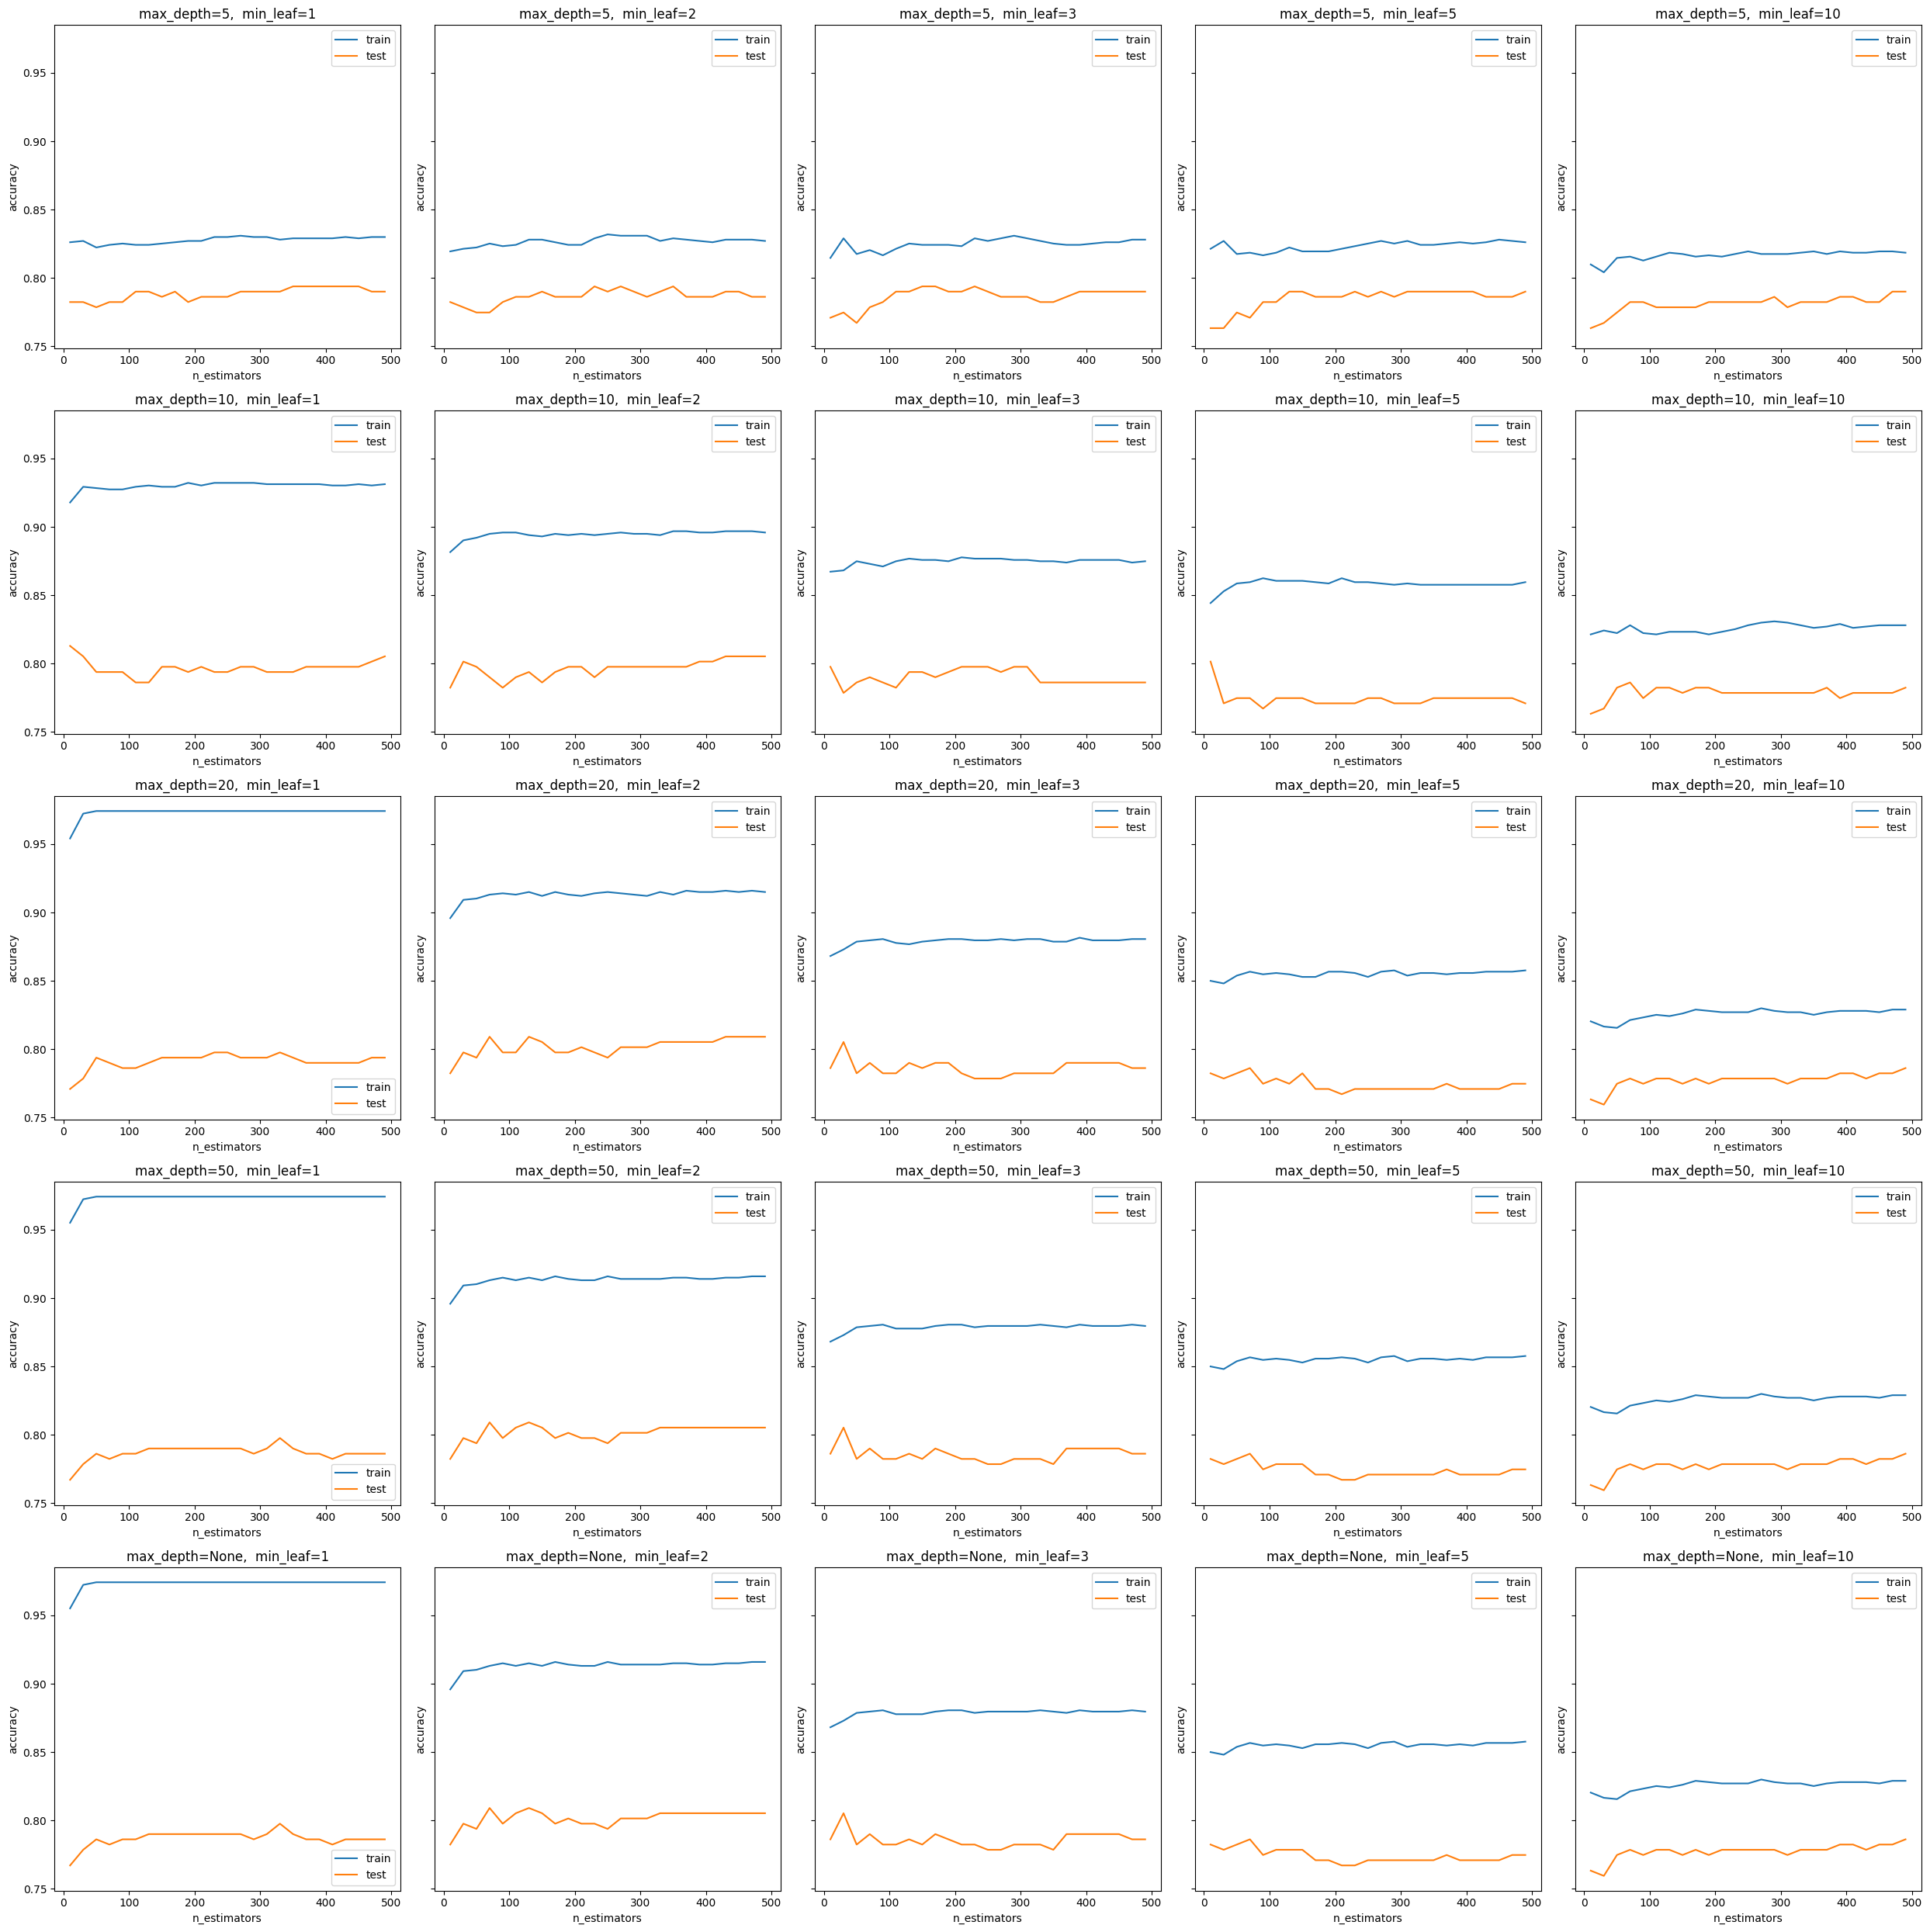

In [630]:
max_depths = [5, 10, 20, 50, None]
min_samples_leafs = [1, 2, 3, 5, 10]
n_estimators_range = range(10, 500, 20)

fig, axes = plt.subplots(len(max_depths), len(min_samples_leafs), figsize=(25, 25), sharey=True)

acc_threshold = 0.8 
best_acc_and_param = []

for i, max_depth in enumerate(max_depths):
    for j, min_samples_leaf in enumerate(min_samples_leafs):

        print(f'{i*len(max_depths) + j}/{len(max_depths)*len(min_samples_leafs)}', end='\r')    # доля выполнения

        train_accs, test_accs = [], []

        for n_est in n_estimators_range:
            rf_pipe = Pipeline([
                ('preprocessor', preprocessor),
                ('model', RandomForestClassifier(
                    n_estimators=n_est,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    class_weight='balanced', # улучшает accuracy на сотые доли, проверено за кадром 
                    random_state=RANDOM_STATE
                ))
            ])
            rf_pipe.fit(X_train, y_train)
            train_accs.append(accuracy_score(y_train, rf_pipe.predict(X_train)))
            test_acc = accuracy_score(y_test, rf_pipe.predict(X_test))
            test_accs.append(test_acc)

            if test_acc >= acc_threshold:
                best_acc_and_param.append({'accuracy': test_acc,
                                    'max_depth': max_depth, 
                                    'min_samples_leaf': min_samples_leaf, 
                                    'n_estimators': n_est})

        ax = axes[i][j]
        ax.plot(n_estimators_range, train_accs, label='train')
        ax.plot(n_estimators_range, test_accs, label='test')
        ax.set_title(f'max_depth={max_depth},  min_leaf={min_samples_leaf}')
        ax.legend()
        ax.set_xlabel('n_estimators')
        ax.set_ylabel('accuracy')

for el in sorted(best_acc_and_param, key=lambda x: x['accuracy'], reverse=True)[:10]:   # берем первые 10 самых лучших-по-accuracy словарей в этом списке 
    print(el, end='\n\n')

plt.tight_layout()
plt.show()

лучшие accuracy дали связки

`'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 10`

и

`'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 70`

но количество деревьев в них слишком мало в плане устойчивости модели -- при другом randomstate результат может быть сильно хуже

поэтому позьмем в качестве итоговой модель с гиперпараметрами

`'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 130`
 

## обучение-предикт-метрики с лучшими гиперпараметрами

### определение модели 

In [631]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
            n_estimators=130,
            max_depth=20,        
            min_samples_leaf=2,
            class_weight='balanced', # улучшает accuracy на сотые доли, проверено за кадром
            random_state=RANDOM_STATE
        )
     )
])

### fit

In [632]:
rf_pipe.fit(X_train, y_train)
None

### важность признаков

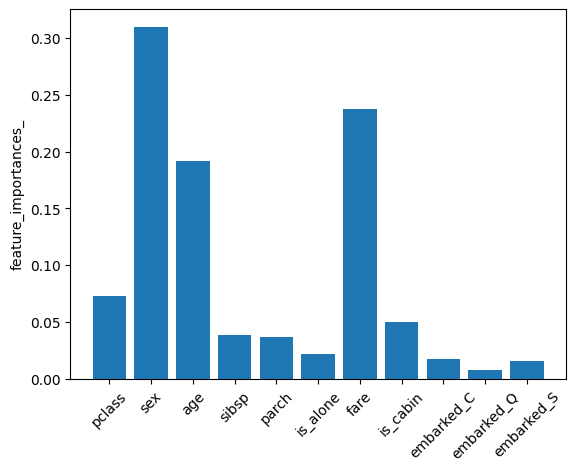

In [633]:
ohe_cols = rf_pipe['preprocessor']['cat']['encoder'].get_feature_names_out(cat_cols)
all_cols = num_cols + list(ohe_cols)

plt.bar(all_cols, rf_pipe['model'].feature_importances_)
plt.xticks(rotation=45)
plt.ylabel('feature_importances_')
plt.show()

ого `fare` (воперки моим ожиданиям) вносит отсносительно большой вклад в выживаемость, сильнее чем `pclass`, что не очевидно

### predict-accuracy

In [634]:
y_pred = rf_pipe.predict(X_test)

accuracy_score(y_test, y_pred)

0.8091603053435115